In [2]:
# Model
from pprint import pprint

from langchain_ollama import ChatOllama

llm = ChatOllama(
    base_url="http://host.docker.internal:11434",
    keep_alive="12m",
    model="qwen3.5:0.8b",
    temperature=0.24,
    think=False,
)
pprint(llm)

# hello_world = llm.invoke("Hello, world!")
# hello_world.pretty_print()
# pprint(hello_world.model_dump(exclude={"content"}))

ChatOllama(model='qwen3.5:0.8b', temperature=0.24, keep_alive='12m', base_url='http://host.docker.internal:11434')


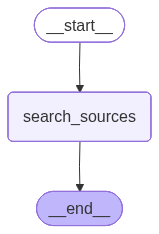

In [3]:
# Search Sources
from typing import TypedDict

import trafilatura
from IPython.display import Image, display
from langchain_community.utilities import SearxSearchWrapper
from langgraph.graph import END, START, StateGraph

from src.prompts import search_sources_prompt_template
from src.subjects import TAROT_CARDS, Subject


class SubjectState(TypedDict):
    subject: Subject
    query: str
    sources: str


def search_sources(state: SubjectState) -> SubjectState:
    print("Searching sources...")
    subject = state["subject"]
    query = search_sources_prompt_template.format(
        subject_name=subject.name,
        category_name=subject.category.name,
    )

    searxng_wrapper = SearxSearchWrapper(searx_host="http://searxng:8080")
    searxng_results = searxng_wrapper.results(query, num_results=12)

    trafilatura_results = []
    for i, searxng_result in enumerate(searxng_results, start=1):
        url = searxng_result.get("link", "")
        title = searxng_result.get("title", "").strip()
        text = trafilatura.extract(
            trafilatura.fetch_url(url),
            include_comments=False,
            include_tables=True,
            no_fallback=False,
        )
        if not text:
            print(f"Warning: No text extracted from URL: {url}")
            continue
        heading = title if title else url
        trafilatura_results.append(
            f"## Search Result {i}: {heading}\n\n**Source:** [{url}]({url})\n\n{text}"
        )

    if not trafilatura_results:
        raise ValueError(f"No content could be extracted for query: {query}")

    sources = "\n\n---\n\n".join(trafilatura_results)

    return {
        "subject": subject,
        "query": query,
        "sources": sources,
    }


graph_builder: StateGraph = StateGraph(SubjectState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", END)
graph_builder = graph_builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

state: SubjectState = {"subject": TAROT_CARDS[0]}
# state = graph_builder.invoke(state)
# pprint(state)

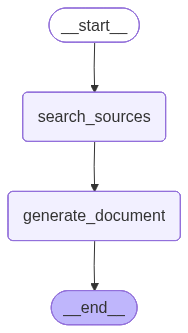

Searching sources...
Generating document from sources...


In [ ]:
# Generate Document from Sources
import re
from typing import NotRequired

import inflect

from src.output import strip_markdown_fences, write_document
from src.prompts import generate_document_from_sources_prompt_template
from src.subjects import Subject

inflect_engine = inflect.engine()


class GenerateDocumentFromSourcesState(TypedDict, SubjectState):
    document: NotRequired[str]


def generate_document(
    state: GenerateDocumentFromSourcesState,
) -> GenerateDocumentFromSourcesState:
    print("Generating document from sources...")
    subject = state["subject"]
    sources = state["sources"]

    messages = generate_document_from_sources_prompt_template.format_messages(
        subject_name=subject.name,
        category_name=subject.category.name,
        category_name_plural=inflect_engine.plural(subject.category.name),
        sources=sources,
    )
    agent_message = llm.invoke(messages)

    document = agent_message.content.strip()
    document = re.sub(r"^```(?:markdown)?\s*\n", "", document)
    document = re.sub(r"\n```\s*$", "", document)

    return {"document": document}


graph_builder: StateGraph = StateGraph(GenerateDocumentFromSourcesState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_node("generate_document", generate_document)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", "generate_document")
graph_builder.add_edge("generate_document", END)
graph_builder = graph_builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

state: GenerateDocumentFromSourcesState = {"subject": TAROT_CARDS[0]}
state = graph_builder.invoke(state)
pprint(state)

In [ ]:
# Generate Document from Source Analysis
from typing import NotRequired, TypedDict

import inflect
from langchain_core.output_parsers import StrOutputParser

from src.prompts import (
    analyze_sources_prompt_template,
    generate_document_prompt_template,
)

inflect_engine = inflect.engine()


class GenerateDocumentFromAnalysisState(TypedDict, GenerateDocumentFromSourcesState):
    source_analysis: NotRequired[str]


str_output_parser = StrOutputParser()


def analyze_sources(state: GenerateDocumentFromAnalysisState) -> dict[str, str]:
    print("Analyzing sources...")
    subject = state["subject"]
    messages = analyze_sources_prompt_template.format_messages(
        subject_name=subject.name,
        category_name=subject.category.name,
        sources=state["sources"],
    )
    return {"source_analysis": str_output_parser.invoke(llm.invoke(messages))}


def generate_document(state: GenerateDocumentFromAnalysisState) -> dict[str, str]:
    print("Generating document from source analysis...")
    subject = state["subject"]
    messages = generate_document_prompt_template.format_messages(
        subject_name=subject.name,
        category_name=subject.category.name,
        category_name_plural=inflect_engine.plural(subject.category.name),
        source_analysis=state.get("source_analysis", ""),
    )
    document = strip_markdown_fences(str_output_parser.invoke(llm.invoke(messages)))
    write_document(subject, document)
    return {"document": document}


graph_builder: StateGraph = StateGraph(GenerateDocumentFromAnalysisState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_node("analyze_sources", analyze_sources)
graph_builder.add_node("generate_document", generate_document)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", "analyze_sources")
graph_builder.add_edge("analyze_sources", "generate_document")
graph_builder.add_edge("generate_document", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

state: GenerateDocumentFromAnalysisState = {"subject": TAROT_CARDS[0]}
# state = graph_builder.invoke(state)
# pprint(state)

In [ ]:
# Generate Affirmations
import operator
from typing import Annotated, NotRequired, TypedDict

import inflect
from langchain_core.output_parsers import StrOutputParser

from src.grammars import GRAMMARS, Grammar
from src.models import (
    Affirmation,
    GeneratedAffirmations,
    GrammarAffirmations,
    ValidationResult,
)
from src.prompts import (
    analyze_document_prompt_template,
    generate_affirmations_prompt_template,
    validate_affirmation_prompt_template,
)

inflect_engine = inflect.engine()
str_output_parser = StrOutputParser()
MAX_RETRIES = 2


class GenerateAffirmationsState(TypedDict, GenerateDocumentFromAnalysisState):
    document_analysis: NotRequired[str]
    grammars: list[Grammar]
    grammar_affirmations: list[GrammarAffirmations]
    validation_failures: Annotated[list[str], operator.add]
    retries: NotRequired[int]


def analyze_document(state: GenerateAffirmationsState) -> dict[str, str]:
    print("Analyzing document...")
    messages = analyze_document_prompt_template.format_messages(
        subject_name=state["subject"].name,
        category_name=state["subject"].category.name,
        document=state["document"],
    )
    return {"document_analysis": str_output_parser.invoke(llm.invoke(messages))}


def generate_affirmations(
    state: GenerateAffirmationsState,
) -> dict[str, list[GrammarAffirmations]]:
    print("Generating affirmations...")

    structured_llm = llm.with_structured_output(GeneratedAffirmations)
    grammar_affirmations: list[GrammarAffirmations] = []

    for grammar in state["grammars"]:
        messages = generate_affirmations_prompt_template.format_messages(
            subject_name=state["subject"].name,
            document_analysis=state["document_analysis"],
            grammar_name=grammar.name,
            grammar_specifiers=", ".join(grammar.specifiers),
            grammar_examples="; ".join(grammar.examples),
            grammar_emoji=grammar.emoji,
        )
        generated: GeneratedAffirmations = structured_llm.invoke(messages)
        affirmations = [Affirmation(text=text) for text in generated.affirmations]
        grammar_affirmations.append(GrammarAffirmations(grammar=grammar, affirmations=affirmations))

    return {"grammar_affirmations": grammar_affirmations}


def validate_affirmations(
    state: GenerateAffirmationsState,
) -> dict[str, list[str] | int]:
    print("Validating affirmations...")

    structured_llm = llm.with_structured_output(ValidationResult)
    failures: list[str] = []

    for grammar_affirmations in state["grammar_affirmations"]:
        grammar = grammar_affirmations.grammar
        for affirmation in grammar_affirmations.affirmations:
            messages = validate_affirmation_prompt_template.format_messages(
                affirmation_text=affirmation.text,
                grammar_name=grammar.name,
                grammar_specifiers=", ".join(grammar.specifiers),
            )
            result: ValidationResult = structured_llm.invoke(messages)  # type: ignore[assignment]

            if not result.valid:
                failure = f"INVALID [{grammar.name}] '{affirmation.text}': {result.reason}"
                failures.append(failure)
                print(f"Validation failure: {failure}")

    if not failures:
        print("Validation: all affirmations passed.")
    else:
        print(f"Validation: {len(failures)} failure(s) logged.")

    return {"validation_failures": failures, "retries": state.get("retries", 0) + 1}


def validate_affirmations_router(state: GenerateAffirmationsState) -> str:
    retries = state.get("retries", 0)
    if state["validation_failures"] and retries < MAX_RETRIES:
        print(f"Retrying generation (attempt {retries}/{MAX_RETRIES})...")
        return "generate_affirmations"
    return END


graph_builder: StateGraph = StateGraph(GenerateAffirmationsState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_node("analyze_sources", analyze_sources)
graph_builder.add_node("generate_document", generate_document)
graph_builder.add_node("analyze_document", analyze_document)
graph_builder.add_node("generate_affirmations", generate_affirmations)
graph_builder.add_node("validate_affirmations", validate_affirmations)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", "analyze_sources")
graph_builder.add_edge("analyze_sources", "generate_document")
graph_builder.add_edge("generate_document", "analyze_document")
graph_builder.add_edge("analyze_document", "generate_affirmations")
graph_builder.add_edge("generate_affirmations", "validate_affirmations")
graph_builder.add_conditional_edges("validate_affirmations", validate_affirmations_router)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

state: GenerateAffirmationsState = {
    "subject": TAROT_CARDS[0],
    "grammars": GRAMMARS,
}
# state = graph_builder.invoke(state)

# print("\n=== SEARCH RESULTS (first 500 chars) ===")
# print(state["sources"][:500])

# print("\n=== ANALYSIS ===")
# print(state["source_analysis"])

# print("\n=== DOCUMENT (first 500 chars) ===")
# print(state["document"][:500])

# print("\n=== DOCUMENT ANALYSIS ===")
# print(state["document_analysis"])

# print("\n=== GENERATED AFFIRMATIONS ===")
# for grammar_affirmation in state["grammar_affirmations"]:
#     print(f"\n{grammar_affirmation.grammar.name}:")
#     for affirmation in grammar_affirmation.affirmations:
#         print(f"  - {affirmation.text}")

# print("\n=== VALIDATION FAILURES ===")
# for failure in state["validation_failures"]:
#     print(f"  {failure}")
# if not state["validation_failures"]:
#     print("  None")